In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir('/content')

['.config', 'sample_data']

In [ ]:
file_path = '/Delinquency_prediction_dataset.xlsx'

import os

print("File exists:", os.path.exists(file_path))
print("File size:", os.path.getsize(file_path), "bytes")

File exists: True
File size: 70059 bytes


In [ ]:
import zipfile

file_path = '/Delinquency_prediction_dataset.xlsx'

print("Valid XLSX:", zipfile.is_zipfile(file_path))

with zipfile.ZipFile(file_path, 'r') as z:
    names = z.namelist()
    print("\nNumber of files inside:", len(names))
    print("\nWorksheet-related files:")

    for name in names:
        if 'worksheet' in name.lower() or 'workbook' in name.lower():
            print(name)


Valid XLSX: True

Number of files inside: 10

Worksheet-related files:
xl/workbook.xml
xl/_rels/workbook.xml.rels
xl/worksheets/sheet1.xml


In [ ]:
!pip install python-calamine -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 4.3 MB/s eta 0:00:00


In [ ]:
df = pd.read_excel('/Delinquency_prediction_dataset.xlsx')

df.head(5)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


In [ ]:
df.shape

(500, 19)

In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
# Check unique values of the target
print("Target values:")
print(df['Delinquent_Account'].value_counts())

print("\nTarget percentages:")
print(df['Delinquent_Account'].value_counts(normalize=True) * 100)

Target values:
Delinquent_Account
0    420
1     80
Name: count, dtype: int64

Target percentages:
Delinquent_Account
0    84.0
1    16.0
Name: proportion, dtype: float64


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts())


 Customer_ID
Customer_ID
CUST0500    1
CUST0001    1
CUST0002    1
CUST0003    1
CUST0484    1
           ..
CUST0009    1
CUST0008    1
CUST0007    1
CUST0006    1
CUST0005    1
Name: count, Length: 500, dtype: int64

 Employment_Status
Employment_Status
Unemployed       93
retired          87
Employed         82
EMP              81
Self-employed    80
employed         77
Name: count, dtype: int64

 Credit_Card_Type
Credit_Card_Type
Gold        118
Student     112
Business    108
Standard     86
Platinum     76
Name: count, dtype: int64

 Location
Location
Los Angeles    107
Phoenix        103
Chicago        103
Houston         95
New York        92
Name: count, dtype: int64

 Month_1
Month_1
On-time    177
Missed     164
Late       159
Name: count, dtype: int64

 Month_2
Month_2
Late       173
Missed     167
On-time    160
Name: count, dtype: int64

 Month_3
Month_3
Late       169
On-time    169
Missed     162
Name: count, dtype: int64

 Month_4
Month_4
Late       181
Missed     160

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,500.0,46.266000,16.187629,18.00,33.000000,46.500000,59.250000,74.000000
Income,461.0,108379.893709,53662.723741,15404.00,62295.000000,107658.000000,155734.000000,199943.000000
Credit_Score,498.0,577.716867,168.881211,301.00,418.250000,586.000000,727.250000,847.000000
Credit_Utilization,500.0,0.491446,0.197103,0.05,0.356486,0.485636,0.634440,1.025843
Missed_Payments,500.0,2.968000,1.946935,0.00,1.000000,3.000000,5.000000,6.000000
Delinquent_Account,500.0,0.160000,0.366973,0.00,0.000000,0.000000,0.000000,1.000000
Loan_Balance,471.0,48654.428875,29395.537273,612.00,23716.500000,45776.000000,75546.500000,99620.000000
Debt_to_Income_Ratio,500.0,0.298862,0.094521,0.10,0.233639,0.301634,0.362737,0.552956
Account_Tenure,500.0,9.740000,5.923054,0.00,5.000000,10.000000,15.000000,19.000000


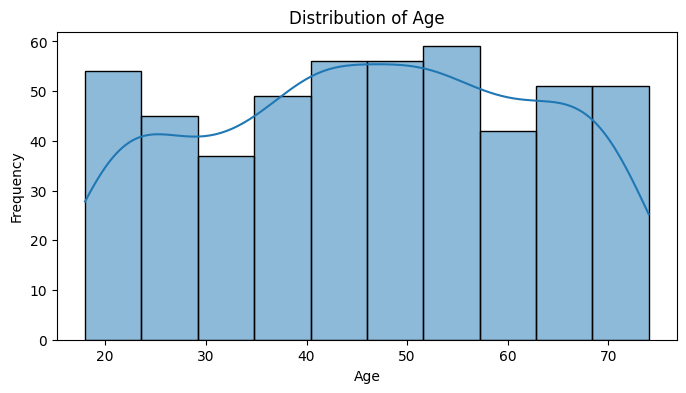

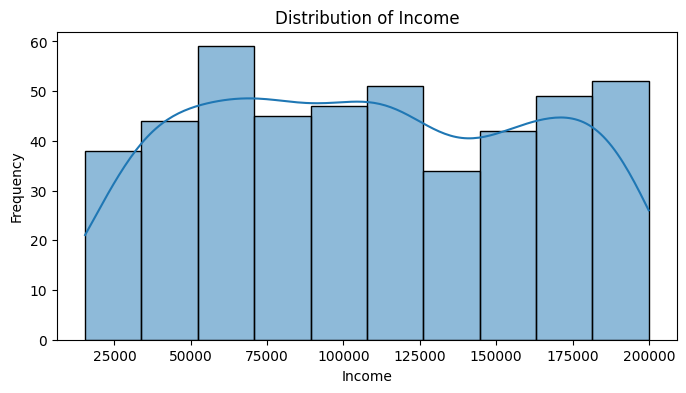

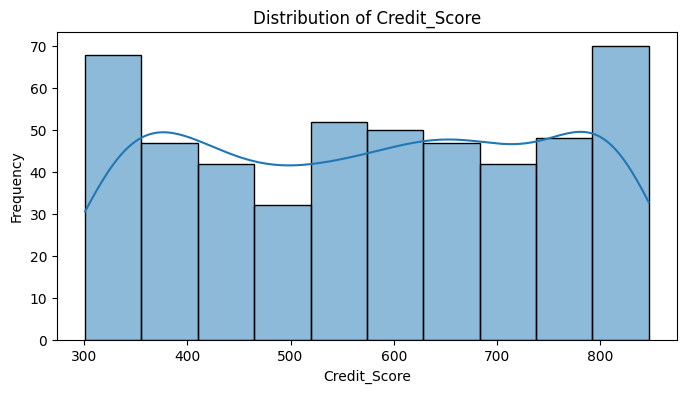

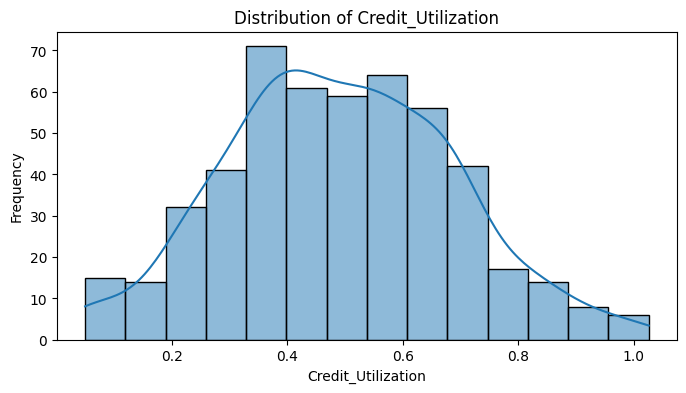

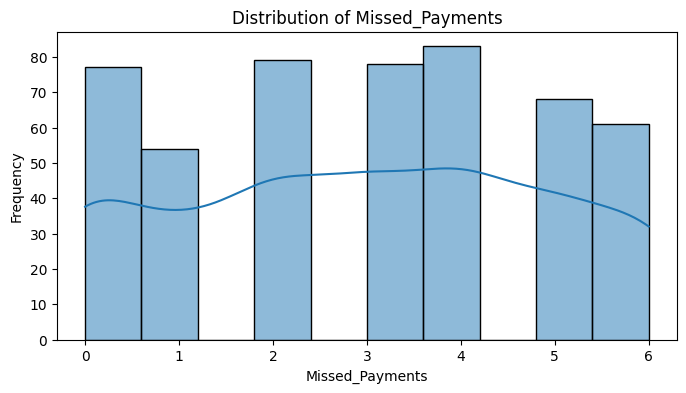

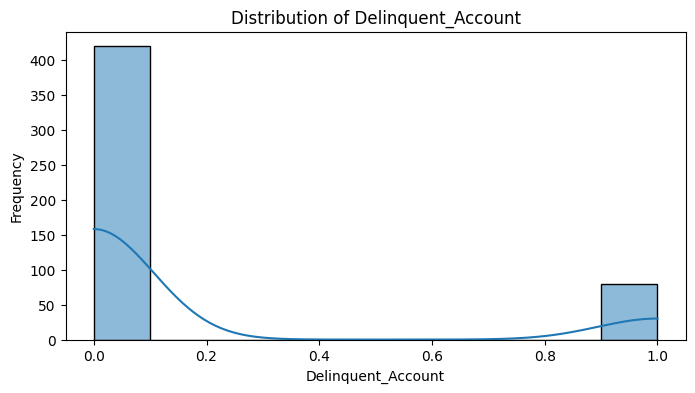

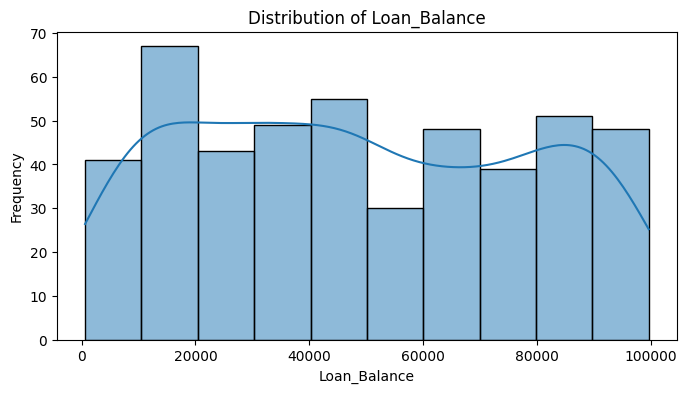

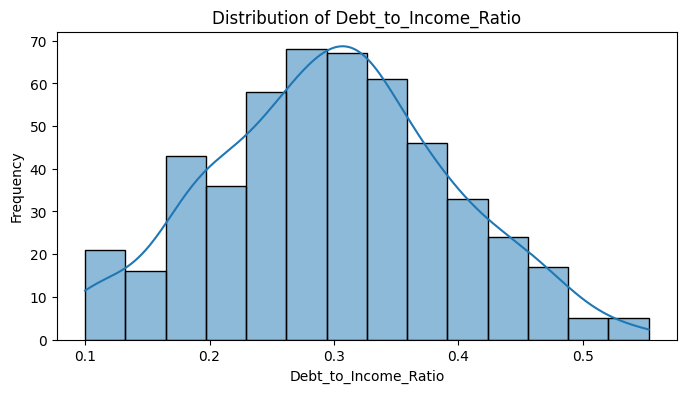

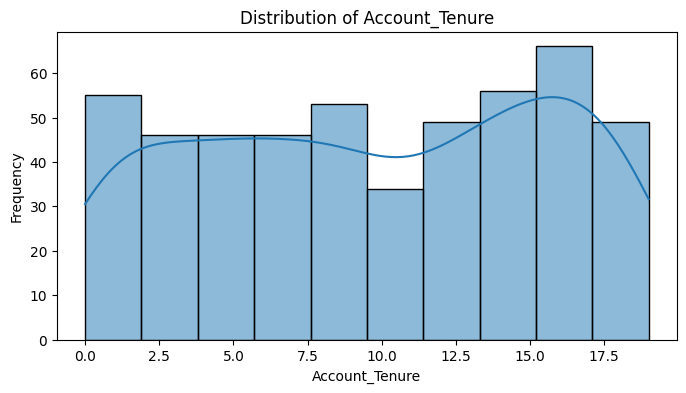

In [29]:
#Univariate EDA Histograms + KDE for numerical variables
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Plot distributions
for col in numerical_cols:
    plt.figure(figsize=(8, 4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.show()

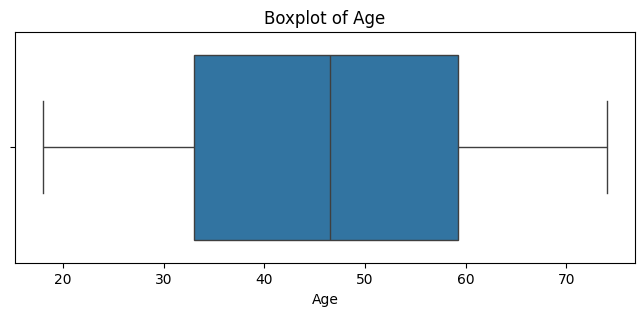

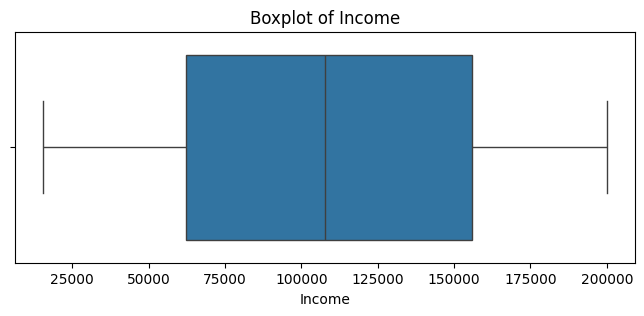

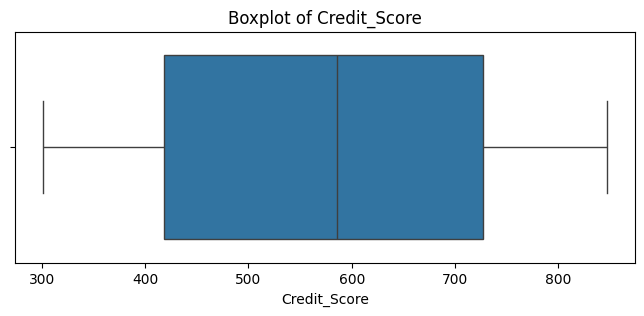

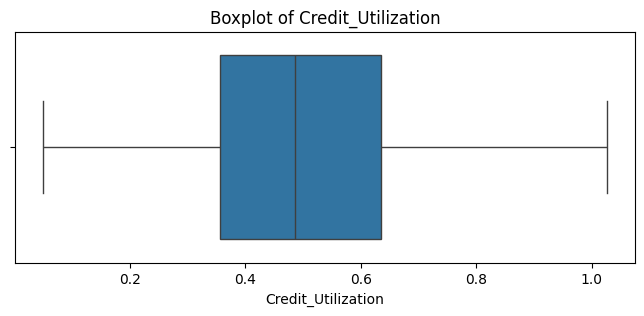

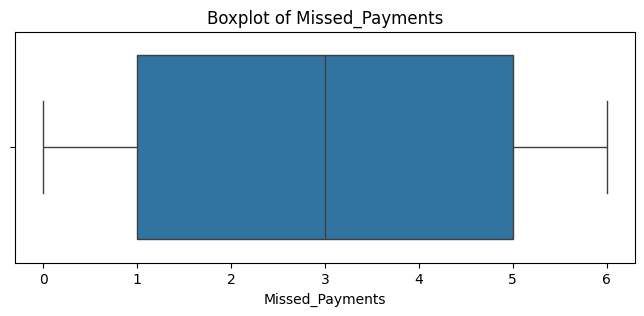

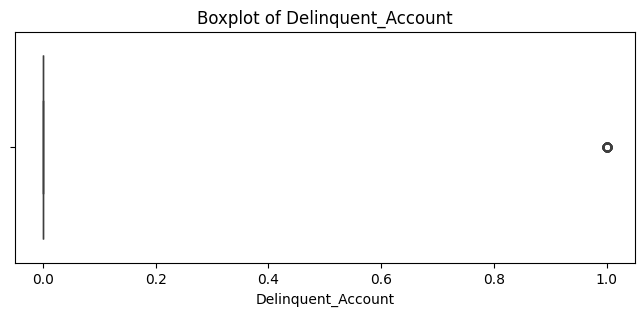

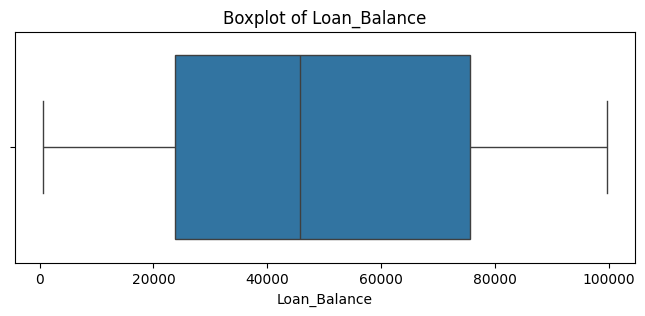

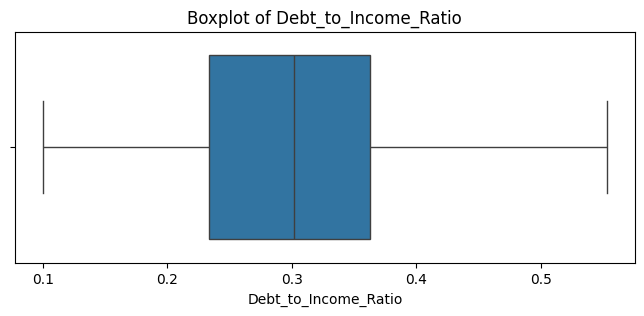

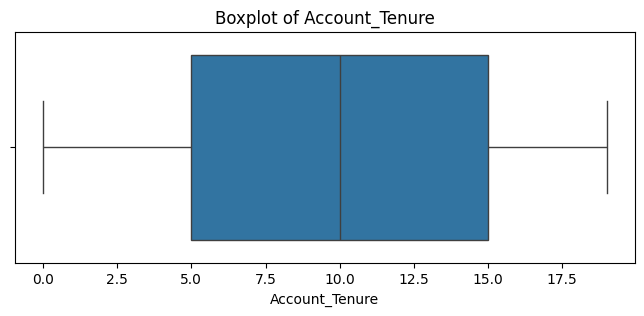

In [33]:
#Boxplots for numerical variables
for col in numerical_cols:
    plt.figure(figsize=(8, 3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

    plt.show()

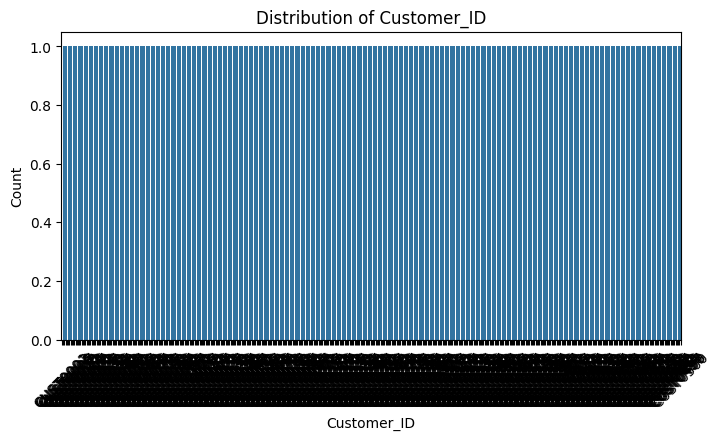

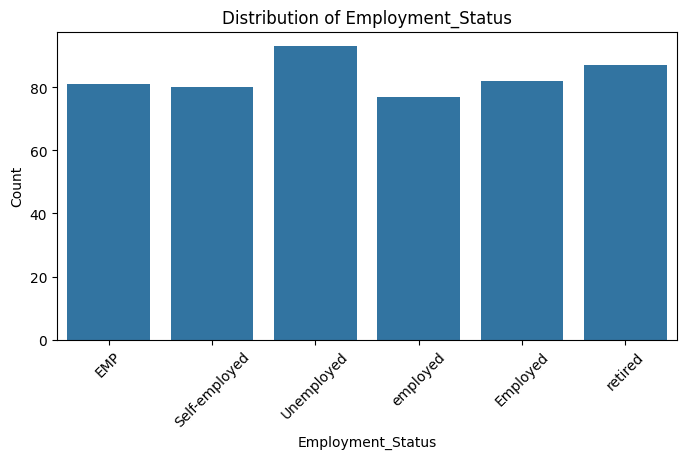

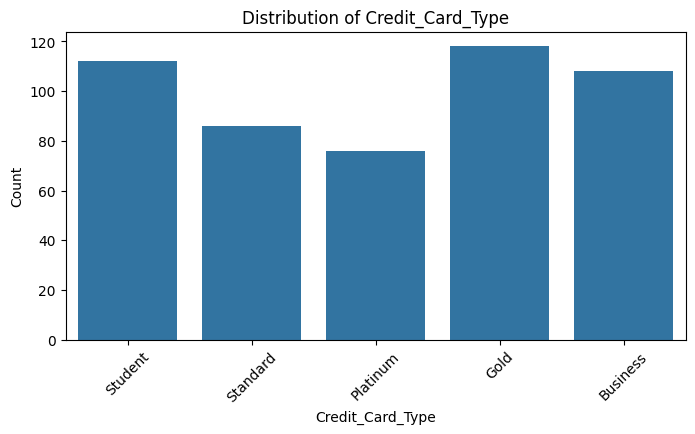

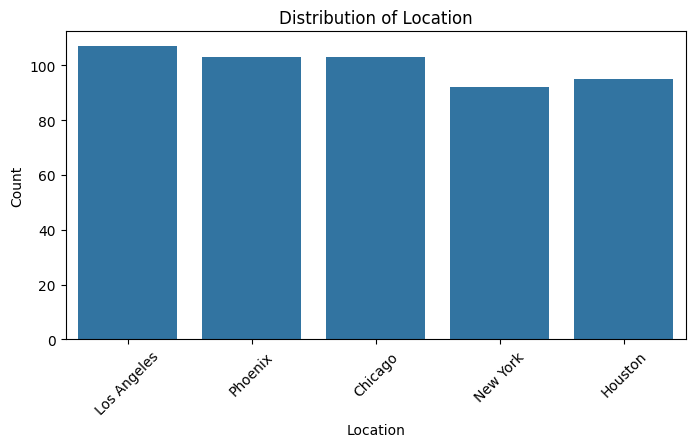

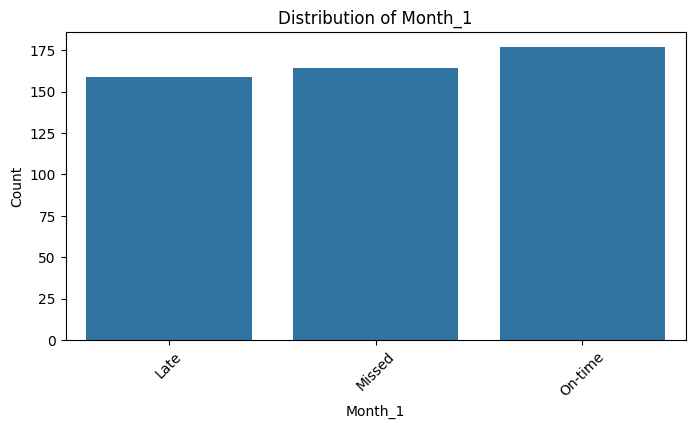

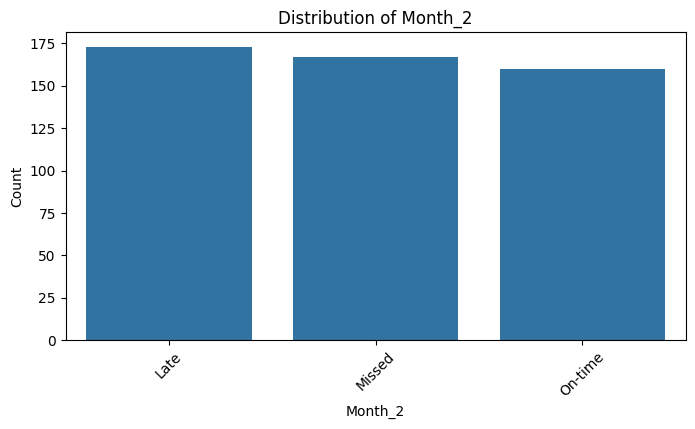

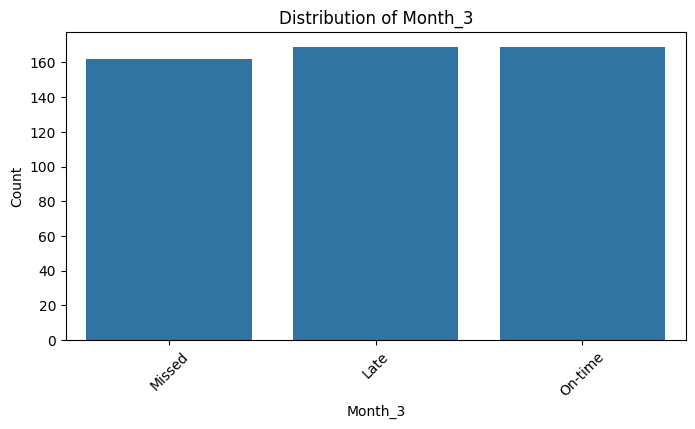

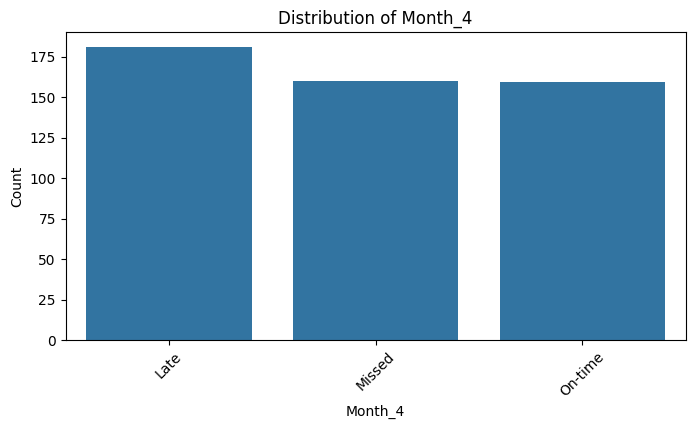

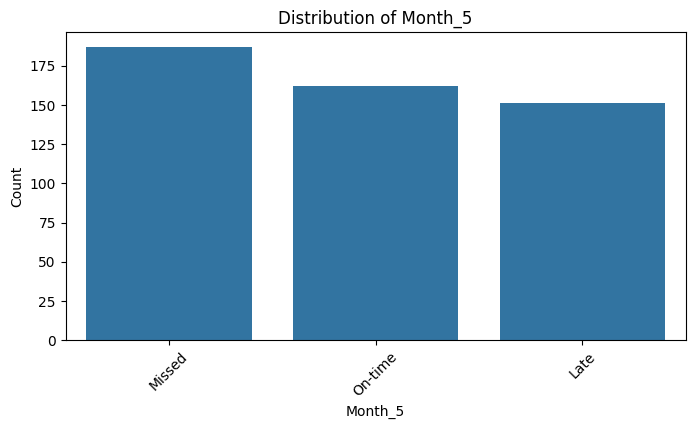

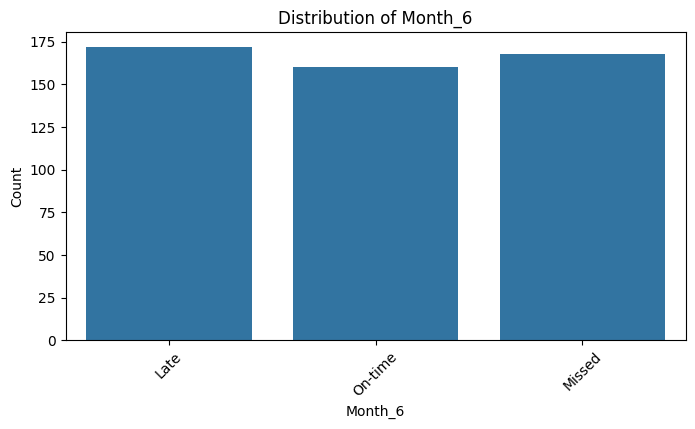

In [32]:
#Univariate analysis of categorical variables
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    plt.figure(figsize=(8, 4))

    sns.countplot(data=df, x=col)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    plt.xticks(rotation=45)
    plt.show()

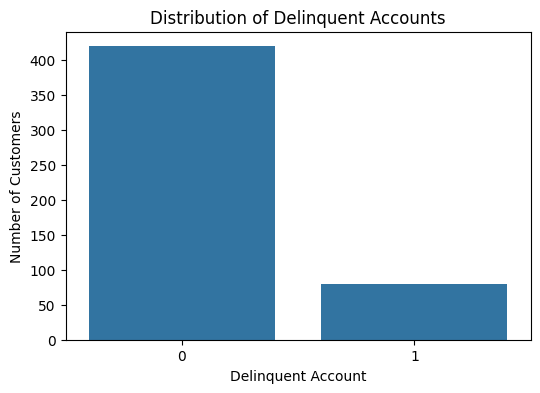

In [34]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Delinquent_Account')

plt.title('Distribution of Delinquent Accounts')
plt.xlabel('Delinquent Account')
plt.ylabel('Number of Customers')

plt.show()

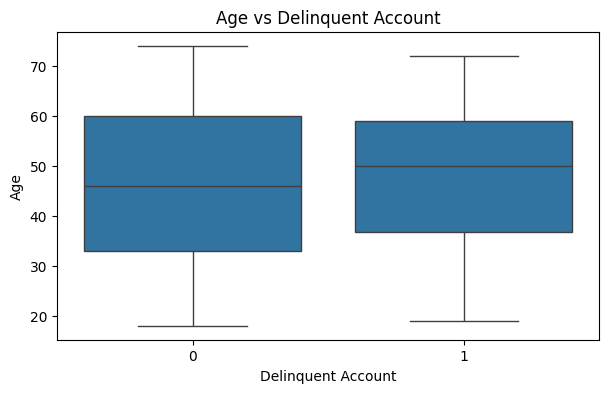

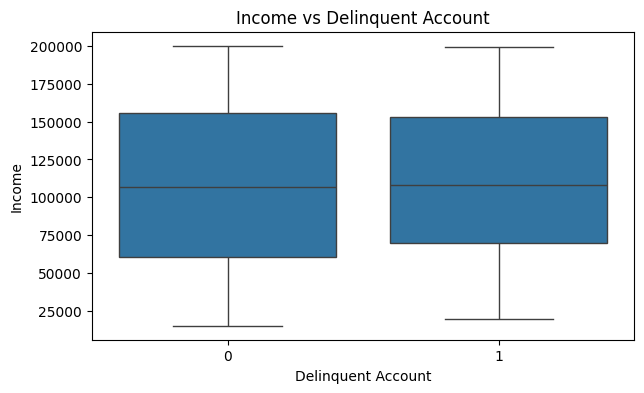

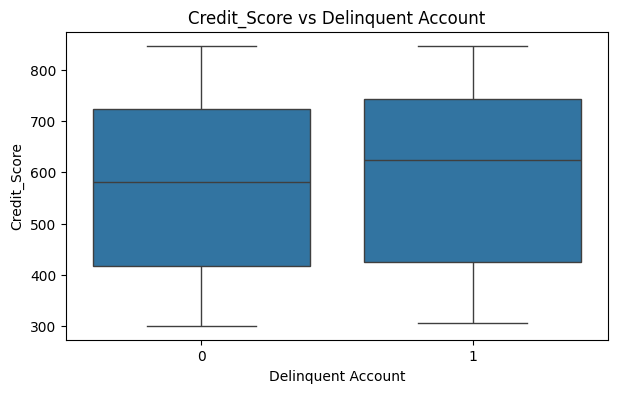

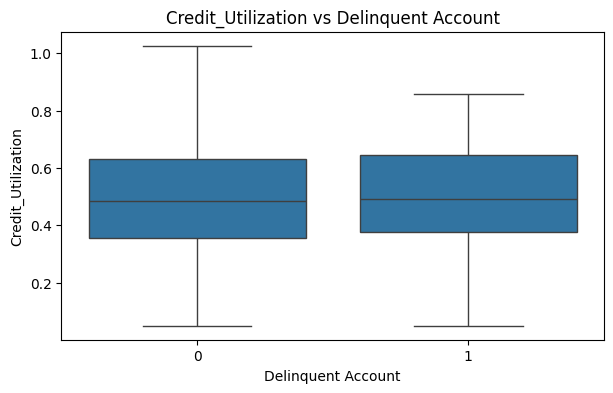

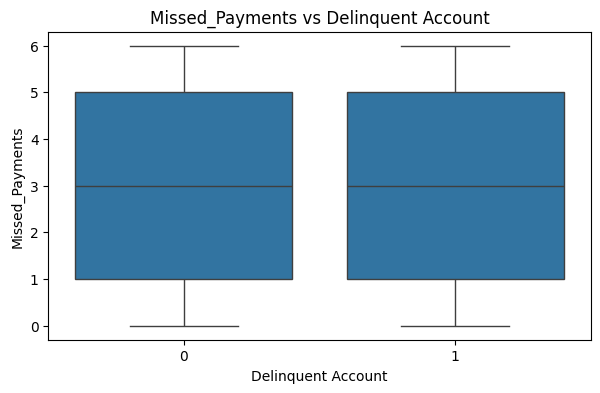

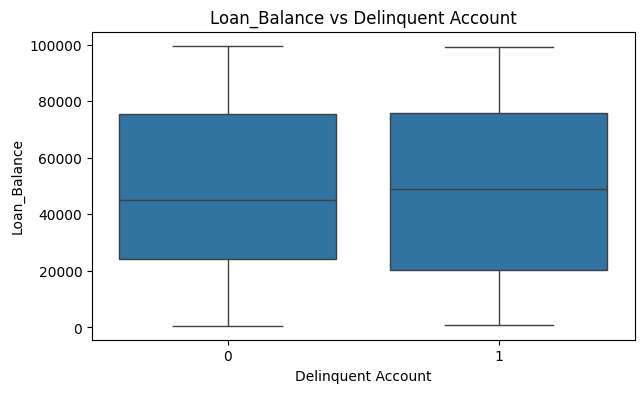

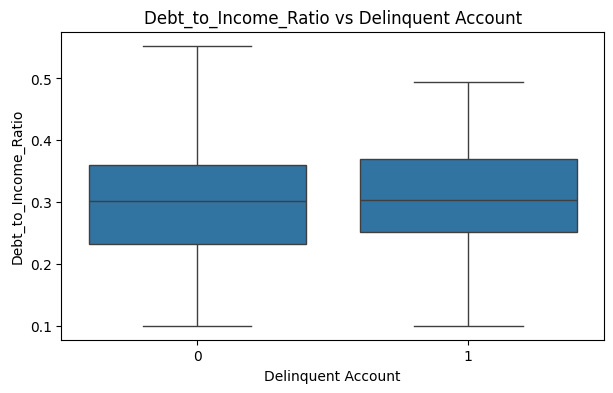

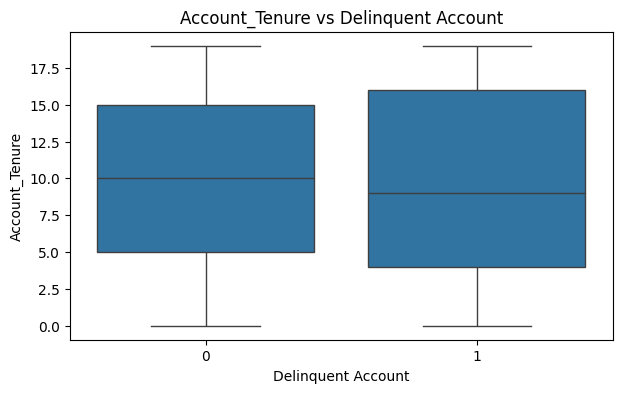

In [35]:
#Bivariate EDA Numerical variables vs Delinquency
features = [
    'Age',
    'Income',
    'Credit_Score',
    'Credit_Utilization',
    'Missed_Payments',
    'Loan_Balance',
    'Debt_to_Income_Ratio',
    'Account_Tenure'
]

for col in features:
    plt.figure(figsize=(7, 4))

    sns.boxplot(data=df, x='Delinquent_Account', y=col)

    plt.title(f'{col} vs Delinquent Account')
    plt.xlabel('Delinquent Account')
    plt.ylabel(col)

    plt.show()

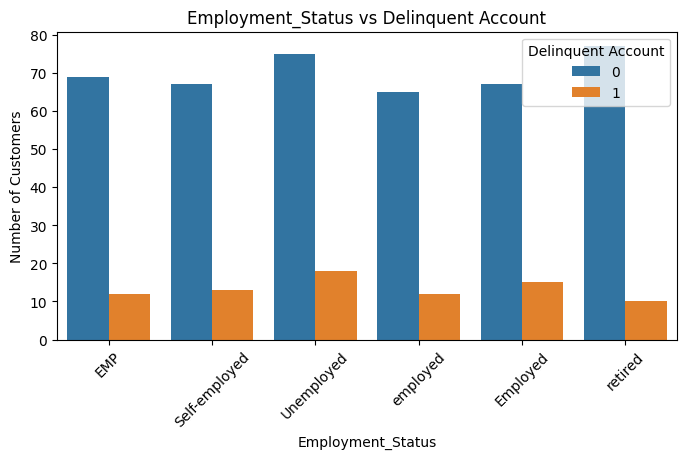

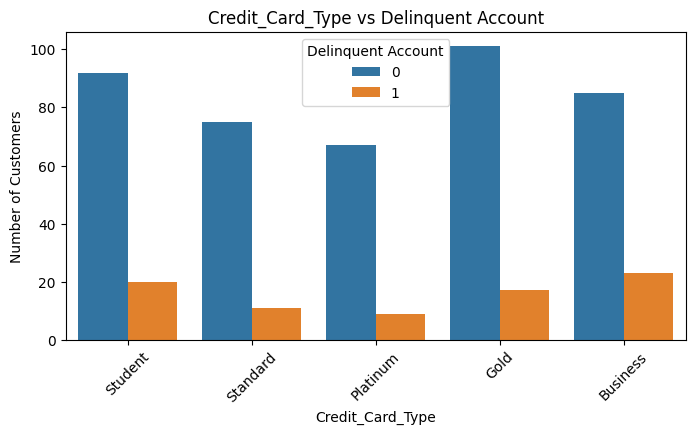

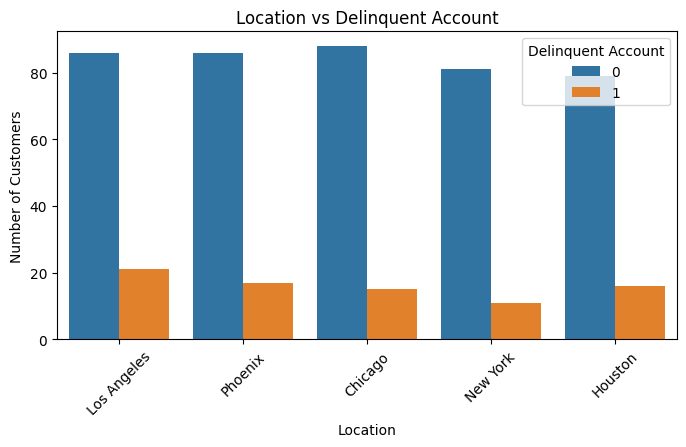

In [36]:
#Categorical variables vs Delinquency
categorical_features = [
    'Employment_Status',
    'Credit_Card_Type',
    'Location'
]

for col in categorical_features:
    plt.figure(figsize=(8, 4))

    sns.countplot(
        data=df,
        x=col,
        hue='Delinquent_Account'
    )

    plt.title(f'{col} vs Delinquent Account')
    plt.xlabel(col)
    plt.ylabel('Number of Customers')

    plt.xticks(rotation=45)
    plt.legend(title='Delinquent Account')

    plt.show()

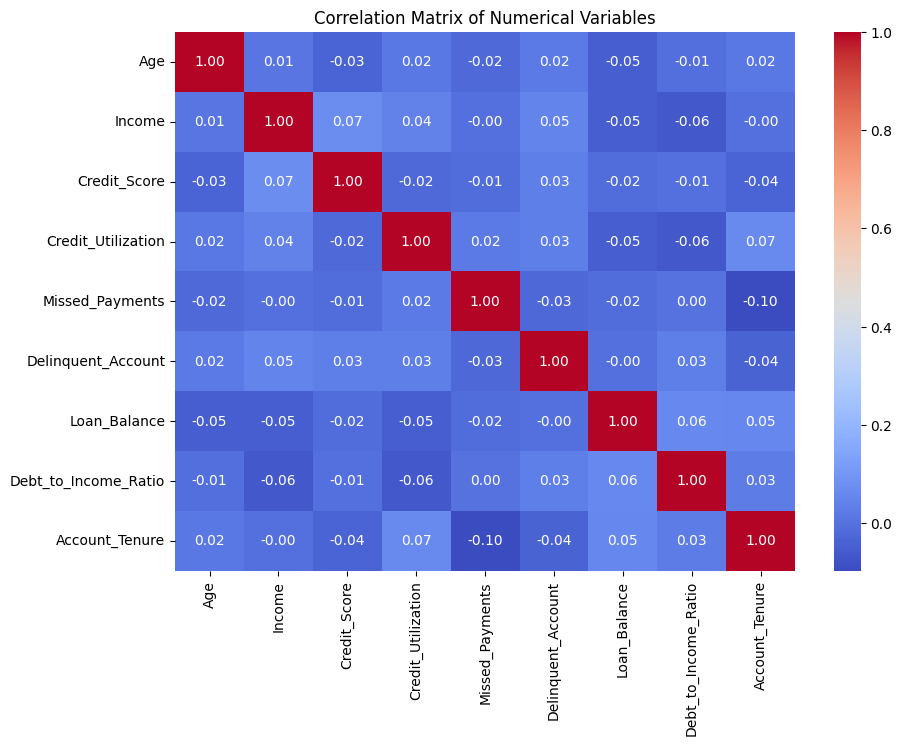

In [37]:
#Multivariate EDA

plt.figure(figsize=(10, 7))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.show()

In [38]:
selected_features = [
    'Credit_Utilization',
    'Debt_to_Income_Ratio',
    'Income',
    'Delinquent_Account'
]

selected_corr = df[selected_features].corr()

print(selected_corr)

                      Credit_Utilization  Debt_to_Income_Ratio    Income  \
Credit_Utilization              1.000000             -0.064661  0.041181   
Debt_to_Income_Ratio           -0.064661              1.000000 -0.064181   
Income                          0.041181             -0.064181  1.000000   
Delinquent_Account              0.034224              0.034386  0.045409   

                      Delinquent_Account  
Credit_Utilization              0.034224  
Debt_to_Income_Ratio            0.034386  
Income                          0.045409  
Delinquent_Account              1.000000  


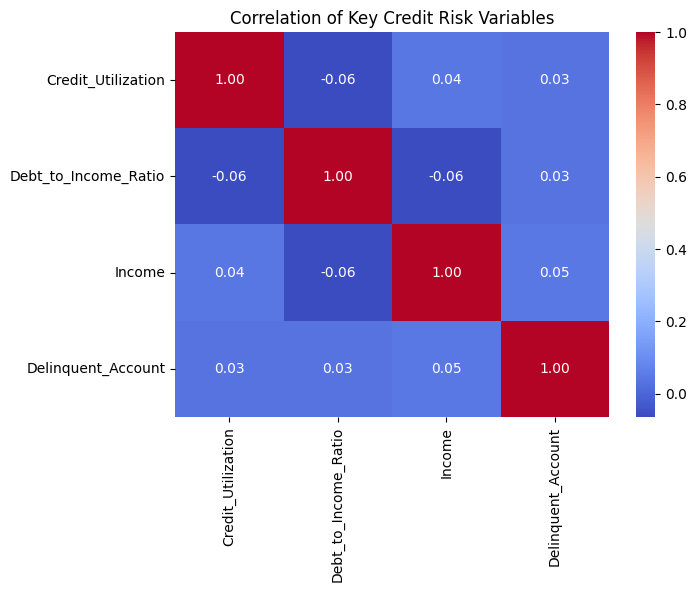

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    selected_corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation of Key Credit Risk Variables')

plt.show()

In [40]:
employment_delinquency = pd.crosstab(
    df['Employment_Status'],
    df['Delinquent_Account'],
    normalize='index'
) * 100

print(employment_delinquency)

Delinquent_Account          0          1
Employment_Status                       
EMP                 85.185185  14.814815
Employed            81.707317  18.292683
Self-employed       83.750000  16.250000
Unemployed          80.645161  19.354839
employed            84.415584  15.584416
retired             88.505747  11.494253


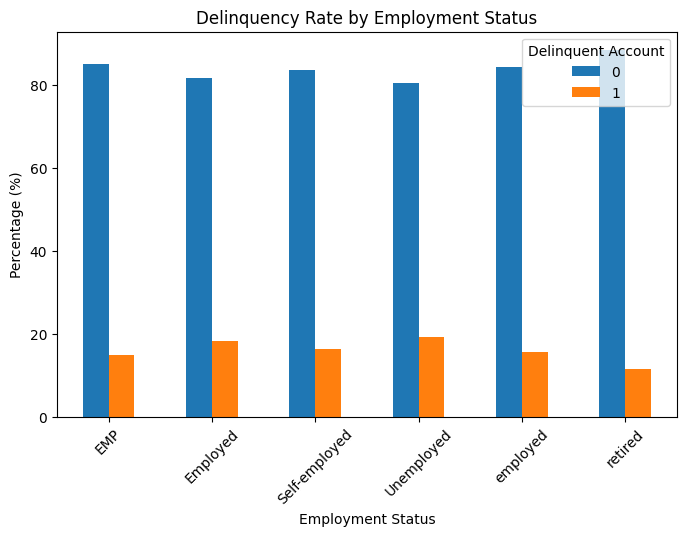

In [41]:
employment_delinquency.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Delinquency Rate by Employment Status')
plt.xlabel('Employment Status')
plt.ylabel('Percentage (%)')

plt.xticks(rotation=45)
plt.legend(title='Delinquent Account')

plt.show()